**ASSIGNMENT 7 - Bagging, Boosting, and Stacked Ensemble Models**

NAME : MADUSSREE RAVI

CSE B

DATE : 02-03-2026

3122235001074

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [9]:
# 1. LOAD DATA
columns = ['ID', 'target'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbc.data', header=None, names=columns)

# Drop ID column as it is not a feature
df.drop('ID', axis=1, inplace=True)

print("Dataset Shape:", df.shape)
df.head()
df['target'] = df['target'].map({'M': 1, 'B': 0})

Dataset Shape: (569, 31)



Missing Values:
 0

Target Class Distribution:
target
0    0.627417
1    0.372583
Name: proportion, dtype: float64


C:\Users\Madussree Ravi\AppData\Local\Temp\ipykernel_12796\851123105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


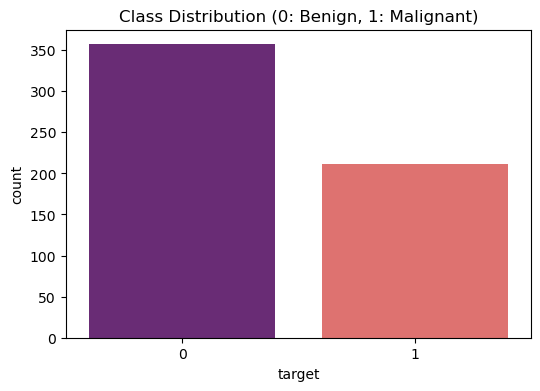

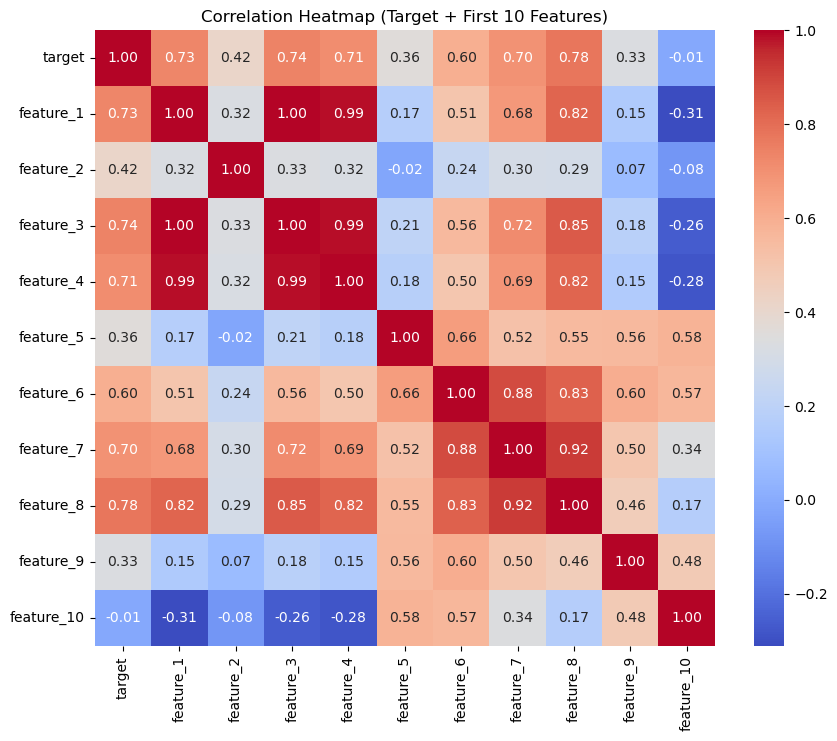

In [12]:
# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---
# Target Balance
print("\nMissing Values:\n", df.isnull().sum().sum())
print("\nTarget Class Distribution:")
print(df['target'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='magma')
plt.title('Class Distribution (0: Benign, 1: Malignant)')
plt.show()

# Heatmap of first 10 features to check for multicollinearity
# (High correlation suggests Bagging/Boosting will be effective)
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :11].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Target + First 10 Features)')
plt.show()


In [11]:
# --- 3. PREPROCESSING & SPLIT ---
X = df.drop('target', axis=1)
y = df['target']

# 80-20 Split as per assignment
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline setup (Scaling is vital for SVM/Logistic Regression in the Stacked model)
scaler = StandardScaler()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is


========== Bagging Results ==========
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



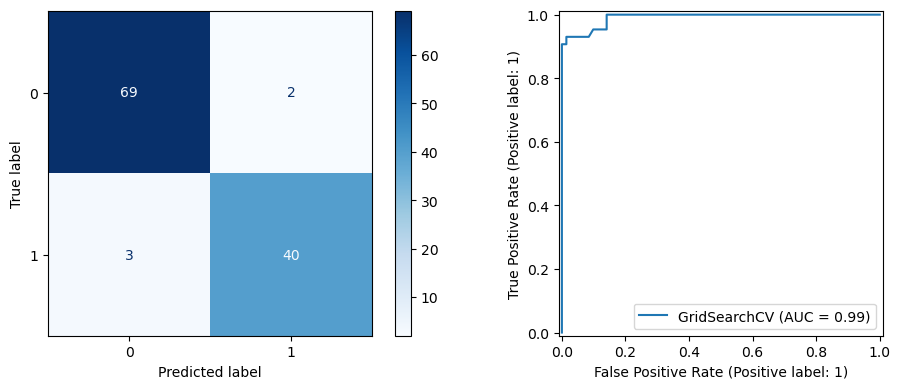


========== Boosting Results ==========
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



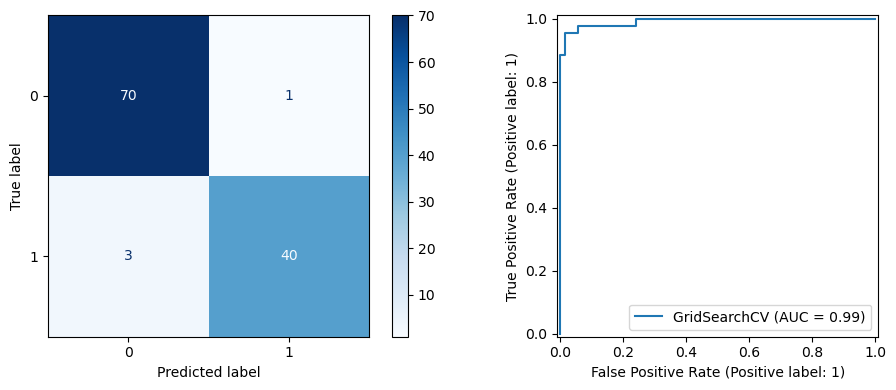


========== Stacking Results ==========
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



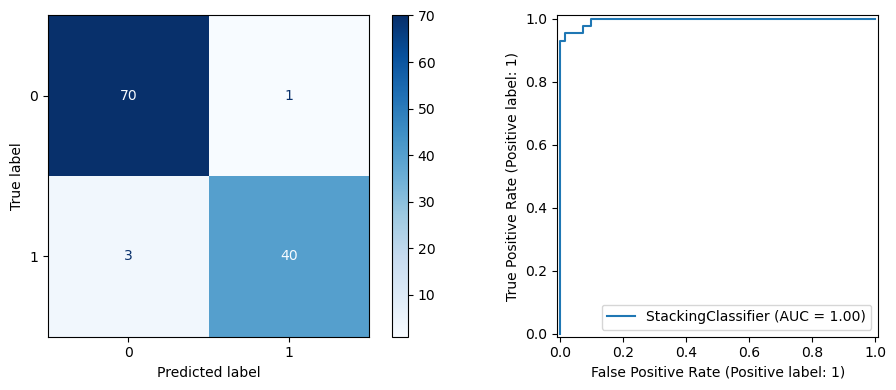

In [13]:
# --- 4. BAGGING ---
bag_pipe = Pipeline([('scaler', scaler), ('model', BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42))])
bag_params = {
    'model__n_estimators': [10, 50, 100],
    'model__max_samples': [0.7, 1.0],
    'model__max_features': [0.7, 1.0]
}
grid_bag = GridSearchCV(bag_pipe, bag_params, cv=5, scoring='accuracy')
grid_bag.fit(X_train, y_train)

# --- 5. BOOSTING (AdaBoost) ---
boost_pipe = Pipeline([('scaler', scaler), ('model', AdaBoostClassifier(random_state=42, algorithm='SAMME'))])
boost_params = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 1.0]
}
grid_boost = GridSearchCV(boost_pipe, boost_params, cv=5, scoring='accuracy')
grid_boost.fit(X_train, y_train)

# --- 6. STACKED ENSEMBLE ---
base_learners = [
    ('svm', Pipeline([('s', StandardScaler()), ('m', SVC(probability=True))])),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(max_depth=5))
]
stack_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())
stack_model.fit(X_train, y_train)

# --- 7. FINAL EVALUATION ---
results = {
    "Bagging": grid_bag,
    "Boosting": grid_boost,
    "Stacking": stack_model
}

for name, model in results.items():
    print(f"\n{'='*10} {name} Results {'='*10}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    
    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
    plt.tight_layout()
    plt.show()